# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Nurzilah hidayati
- **Email:** nurzilah.hyt@gmail.com
- **ID Dicoding:** nurzilah_hidayati

## Menentukan Pertanyaan Bisnis

Pertanyaan bisnis dirumuskan menggunakan framework **SMART Question** agar analisis lebih terarah dan menghasilkan insight yang dapat ditindaklanjuti.

**Pertanyaan 1:**
> Kategori produk apa yang menghasilkan total pendapatan tertinggi dan bagaimana tren penjualannya secara bulanan sepanjang periode 2017–2018?

**Breakdown SMART:**
- **Specific**: Fokus pada kategori produk dan tren pendapatan bulanan.
- **Measurable**: Diukur dengan total `payment_value` per kategori per bulan.
- **Action-Oriented**: Hasil analisis membantu tim marketing menentukan kategori prioritas untuk kampanye promosi.
- **Relevant**: Memahami kategori terlaris adalah inti dari strategi bisnis e-commerce.
- **Time-bound**: Dibatasi pada periode 2017–2018 (data yang valid dan lengkap).

**Pertanyaan 2:**
> Bagaimana distribusi waktu pengiriman rata-rata di setiap negara bagian (state) Brasil, dan negara bagian mana yang memiliki performa pengiriman terburuk selama tahun 2017–2018?

**Breakdown SMART:**
- **Specific**: Fokus pada waktu pengiriman per state.
- **Measurable**: Diukur dengan rata-rata `delivery_days` per state.
- **Action-Oriented**: Mengidentifikasi region bermasalah untuk diprioritaskan dalam perbaikan logistik.
- **Relevant**: Kecepatan pengiriman langsung memengaruhi customer satisfaction dan review score.
- **Time-bound**: Dibatasi pada periode 2017–2018.

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print("Library berhasil diimport!")

Library berhasil diimport!


## Data Wrangling

### Gathering Data

Pada tahap ini, seluruh dataset dari E-Commerce Public Dataset dimuat ke dalam DataFrame menggunakan `pandas`. Dataset terdiri dari 9 tabel yang saling berelasi melalui `order_id`, `customer_id`, `product_id`, dan `seller_id`.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load semua dataset
DATA_PATH = '/content/drive/MyDrive/AnalisisData-Dicoding/E-commerce-public-dataset/dataset/'

customers_df = pd.read_csv(DATA_PATH + 'customers_dataset.csv')
geolocation_df = pd.read_csv(DATA_PATH + 'geolocation_dataset.csv')
order_items_df = pd.read_csv(DATA_PATH + 'order_items_dataset.csv')
order_payments_df = pd.read_csv(DATA_PATH + 'order_payments_dataset.csv')
order_reviews_df = pd.read_csv(DATA_PATH + 'order_reviews_dataset.csv')
orders_df = pd.read_csv(DATA_PATH + 'orders_dataset.csv')
products_df = pd.read_csv(DATA_PATH + 'products_dataset.csv')
sellers_df = pd.read_csv(DATA_PATH + 'sellers_dataset.csv')
cat_translation_df = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

# Parse kolom tanggal
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col])

print("=== Ringkasan Dataset ===")
datasets = {
    'customers_df': customers_df, 'order_items_df': order_items_df,
    'order_payments_df': order_payments_df, 'order_reviews_df': order_reviews_df,
    'orders_df': orders_df, 'products_df': products_df,
    'sellers_df': sellers_df, 'cat_translation_df': cat_translation_df
}
for name, df in datasets.items():
    print(f"{name:25s}: {df.shape[0]:>7,} baris x {df.shape[1]} kolom")

=== Ringkasan Dataset ===
customers_df             :  99,441 baris x 5 kolom
order_items_df           : 112,650 baris x 7 kolom
order_payments_df        : 103,886 baris x 5 kolom
order_reviews_df         :  99,224 baris x 7 kolom
orders_df                :  99,441 baris x 8 kolom
products_df              :  32,951 baris x 9 kolom
sellers_df               :   3,095 baris x 4 kolom
cat_translation_df       :      71 baris x 2 kolom


**Insight:**
- Dataset terdiri dari 8 tabel utama dengan total ratusan ribu baris.
- `orders_df` adalah tabel pusat yang menghubungkan seluruh dataset.
- Kolom tanggal pada `orders_df` berhasil dikonversi ke tipe `datetime`.

### Assessing Data

#### 1. Mengidentifikasi Missing Values

In [ ]:
print("=== Missing Values per DataFrame ===\n")
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing) > 0:
        print(f"--- {name} ---")
        for col, cnt in missing.items():
            pct = cnt / len(df) * 100
            print(f"  {col}: {cnt:,} ({pct:.1f}%)")
        print()

=== Missing Values per DataFrame ===

--- order_reviews_df ---
  review_comment_title: 87,656 (88.3%)
  review_comment_message: 58,247 (58.7%)

--- orders_df ---
  order_approved_at: 160 (0.2%)
  order_delivered_carrier_date: 1,783 (1.8%)
  order_delivered_customer_date: 2,965 (3.0%)

--- products_df ---
  product_category_name: 610 (1.9%)
  product_name_lenght: 610 (1.9%)
  product_description_lenght: 610 (1.9%)
  product_photos_qty: 610 (1.9%)
  product_weight_g: 2 (0.0%)
  product_length_cm: 2 (0.0%)
  product_height_cm: 2 (0.0%)
  product_width_cm: 2 (0.0%)



**Steps to Take:**
- `orders_df`: Baris dengan `order_delivered_customer_date` null kemungkinan adalah pesanan yang belum terkirim (status bukan `delivered`). Akan difilter saat analisis waktu pengiriman.
- `products_df`: 610 baris tanpa `product_category_name` akan diisi dengan 'unknown' saat analisis kategori.
- `order_reviews_df`: Kolom `review_comment_title` dan `review_comment_message` memiliki banyak null karena komentar bersifat opsional — tidak perlu ditangani.

#### 2. Mengidentifikasi Duplicate Data

In [ ]:
print("=== Cek Duplikasi ===\n")
for name, df in datasets.items():
    dups = df.duplicated().sum()
    print(f"{name:25s}: {dups:,} baris duplikat")

=== Cek Duplikasi ===

customers_df             : 0 baris duplikat
order_items_df           : 0 baris duplikat
order_payments_df        : 0 baris duplikat
order_reviews_df         : 0 baris duplikat
orders_df                : 0 baris duplikat
products_df              : 0 baris duplikat
sellers_df               : 0 baris duplikat
cat_translation_df       : 0 baris duplikat


**Steps to Take:**
- Tidak ada duplikasi baris penuh pada semua tabel. Data cukup bersih.
- Namun perlu diperhatikan bahwa satu `order_id` dapat memiliki beberapa `payment_sequential` di `order_payments_df` (pembayaran cicilan/multi-metode) — ini bukan duplikat.

#### 3. Mengidentifikasi Invalid/Inaccurate Values

In [ ]:
# Cek order status distribution
print("=== Distribusi Order Status ===")
print(orders_df['order_status'].value_counts())
print()

# Cek payment type
print("=== Distribusi Payment Type ===")
print(order_payments_df['payment_type'].value_counts())
print()

# Cek rentang tanggal
print("=== Rentang Tanggal Order ===")
print(f"Dari: {orders_df['order_purchase_timestamp'].min()}")
print(f"Hingga: {orders_df['order_purchase_timestamp'].max()}")
print()

# Cek data 2016 — sangat sedikit (partial year)
print("=== Jumlah Order per Tahun ===")
orders_df['year'] = orders_df['order_purchase_timestamp'].dt.year
print(orders_df['year'].value_counts().sort_index())

=== Distribusi Order Status ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

=== Distribusi Payment Type ===
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

=== Rentang Tanggal Order ===
Dari: 2016-09-04 21:15:19
Hingga: 2018-10-17 17:30:18

=== Jumlah Order per Tahun ===
year
2016      329
2017    45101
2018    54011
Name: count, dtype: int64


**Steps to Take:**
- Terdapat 3 baris dengan `payment_type = 'not_defined'` — akan diexclude saat analisis pembayaran.
- Data tahun 2016 sangat sedikit (hanya 329 order) karena platform baru mulai beroperasi. Analisis tren akan difokuskan pada **2017–2018**.
- Pesanan dengan status bukan `delivered` tidak relevan untuk analisis waktu pengiriman.

### Cleaning Data

#### Fix 1: Mengisi Missing Values pada products_df

In [ ]:
# Isi product_category_name yang null dengan 'unknown'
products_df['product_category_name'].fillna('unknown', inplace=True)

# Verifikasi
print("Sisa missing product_category_name:", products_df['product_category_name'].isnull().sum())

Sisa missing product_category_name: 0


#### Fix 2: Filter Data Relevan (2017–2018, status delivered)

In [ ]:
# Filter hanya tahun 2017-2018 untuk analisis tren
orders_2017_2018 = orders_df[orders_df['order_purchase_timestamp'].dt.year.isin([2017, 2018])].copy()
print(f"Orders 2017-2018: {len(orders_2017_2018):,} baris")

# Filter hanya delivered orders untuk analisis pengiriman
delivered_orders = orders_df[
    (orders_df['order_status'] == 'delivered') &
    (orders_df['order_delivered_customer_date'].notna())
].copy()
print(f"Delivered orders: {len(delivered_orders):,} baris")

# Hitung waktu pengiriman
delivered_orders['delivery_days'] = (
    delivered_orders['order_delivered_customer_date'] -
    delivered_orders['order_purchase_timestamp']
).dt.days

# Hapus outlier waktu pengiriman (> 60 hari — kemungkinan data error)
q99 = delivered_orders['delivery_days'].quantile(0.99)
print(f"\n99th percentile delivery days: {q99:.0f}")
delivered_orders_clean = delivered_orders[delivered_orders['delivery_days'] <= q99].copy()
print(f"Setelah cleaning outlier: {len(delivered_orders_clean):,} baris")

Orders 2017-2018: 99,112 baris
Delivered orders: 96,470 baris

99th percentile delivery days: 46
Setelah cleaning outlier: 95,590 baris


#### Fix 3: Remove Payment Type 'not_defined'

In [ ]:
order_payments_clean = order_payments_df[order_payments_df['payment_type'] != 'not_defined'].copy()
print(f"Payment data sebelum: {len(order_payments_df):,}")
print(f"Payment data sesudah: {len(order_payments_clean):,}")
print(f"Dihapus: {len(order_payments_df) - len(order_payments_clean):,} baris")

Payment data sebelum: 103,886
Payment data sesudah: 103,883
Dihapus: 3 baris


**Insight:**
- Proses cleaning berhasil mengatasi 3 masalah utama: missing values pada kategori produk, data tidak relevan (tahun 2016 dan non-delivered orders), serta invalid payment type.
- Data siap digunakan untuk tahap EDA.

## Exploratory Data Analysis (EDA)

### Explore Pertanyaan 1: Pendapatan per Kategori & Tren Bulanan

In [ ]:
# Gabungkan tabel yang diperlukan
products_en = products_df.merge(cat_translation_df, on='product_category_name', how='left')
products_en['product_category_name_english'].fillna(products_en['product_category_name'], inplace=True)

order_value = order_payments_clean.groupby('order_id')['payment_value'].sum().reset_index()
order_value.rename(columns={'payment_value': 'total_payment'}, inplace=True)

# Gabungkan semua
main_df = (orders_2017_2018
    .merge(order_items_df, on='order_id', how='inner')
    .merge(products_en[['product_id','product_category_name_english']], on='product_id', how='left')
    .merge(order_value, on='order_id', how='left')
)

main_df['year_month'] = main_df['order_purchase_timestamp'].dt.to_period('M')

# Top 10 kategori berdasarkan total revenue
category_revenue = (main_df.groupby('product_category_name_english')['total_payment']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index())

print("=== Top 10 Kategori Berdasarkan Revenue ===")
print(category_revenue.to_string(index=False))

# Tren bulanan total revenue
monthly_revenue = main_df.groupby('year_month')['total_payment'].sum().reset_index()
monthly_revenue['year_month_str'] = monthly_revenue['year_month'].astype(str)
print(f"\n=== Tren Revenue Bulanan ===")
print(monthly_revenue[['year_month_str','total_payment']].to_string(index=False))

=== Top 10 Kategori Berdasarkan Revenue ===
product_category_name_english  total_payment
               bed_bath_table     1710261.96
                health_beauty     1651310.96
        computers_accessories     1582933.75
                watches_gifts     1425748.64
              furniture_decor     1419051.39
               sports_leisure     1388200.45
                   housewares     1092021.61
                         auto      849577.63
                 garden_tools      836815.56
                   cool_stuff      778362.59

=== Tren Revenue Bulanan ===
year_month_str  total_payment
       2017-01      187779.41
       2017-02      344134.79
       2017-03      526961.66
       2017-04      505665.53
       2017-05      724504.55
       2017-06      600753.27
       2017-07      737293.08
       2017-08      870105.90
       2017-09     1015849.57
       2017-10     1021169.27
       2017-11     1583869.01
       2017-12     1042855.86
       2018-01     1408365.65
       2018

**Insight:**
- Kategori `health_beauty`, `watches_gifts`, dan `bed_bath_table` konsisten menjadi kontributor revenue tertinggi.
- Terjadi lonjakan signifikan pada bulan November 2017, kemungkinan besar karena event **Black Friday / Harbolnas**.
- Revenue bulanan secara umum menunjukkan tren pertumbuhan positif dari 2017 ke 2018.

### Explore Pertanyaan 2: Performa Pengiriman per State

In [ ]:
# Gabungkan dengan data customer untuk mendapatkan state
delivery_analysis = (delivered_orders_clean
    .merge(customers_df[['customer_id','customer_state']], on='customer_id', how='left')
)

# Rata-rata waktu pengiriman per state
state_delivery = (delivery_analysis
    .groupby('customer_state')
    .agg(
        avg_delivery_days=('delivery_days', 'mean'),
        median_delivery_days=('delivery_days', 'median'),
        total_orders=('order_id', 'count'),
        on_time_rate=('delivery_days', lambda x: (x <= delivery_analysis.loc[x.index, 'delivery_days'].quantile(0.9)).mean())
    )
    .reset_index()
    .sort_values('avg_delivery_days', ascending=False)
)

# On-time: actual <= estimated
delivery_analysis['on_time'] = (
    delivery_analysis['order_delivered_customer_date'] <=
    delivery_analysis['order_estimated_delivery_date']
)
state_ontime = delivery_analysis.groupby('customer_state')['on_time'].mean().reset_index()
state_ontime.columns = ['customer_state', 'on_time_rate']

state_delivery = state_delivery.drop(columns=['on_time_rate']).merge(state_ontime, on='customer_state')

print("=== Waktu Pengiriman per State (Terburuk → Terbaik) ===")
print(state_delivery[['customer_state','avg_delivery_days','median_delivery_days','total_orders','on_time_rate']].head(10).to_string(index=False))

print(f"\n=== State dengan Pengiriman Tercepat ===")
print(state_delivery.tail(5)[['customer_state','avg_delivery_days','on_time_rate']].to_string(index=False))

=== Waktu Pengiriman per State (Terburuk → Terbaik) ===
customer_state  avg_delivery_days  median_delivery_days  total_orders  on_time_rate
            AM          24.830986                  25.0           142      0.978873
            AP          24.303030                  24.0            66      0.969697
            AL          22.684211                  21.0           380      0.794737
            PA          21.431591                  20.0           899      0.918799
            RR          21.277778                  22.0            36      1.000000
            MA          19.913669                  18.0           695      0.828777
            AC          19.397436                  18.0            78      0.987179
            SE          19.083333                  17.0           324      0.873457
            CE          19.052803                  18.0          1231      0.878960
            PB          18.946429                  17.0           504      0.912698

=== State dengan Pe

**Insight:**
- State di wilayah **utara dan timur laut Brasil** (RR, AP, AM, AL, PA) memiliki rata-rata waktu pengiriman paling lama (>20 hari), kemungkinan karena infrastruktur logistik yang kurang memadai.
- State **SP (São Paulo)** memiliki waktu pengiriman tercepat karena merupakan pusat distribusi utama.
- On-time rate secara keseluruhan cukup tinggi (>90%), namun beberapa state terpencil memiliki rate lebih rendah.

## Analisis Lanjutan: RFM Analysis

**Tujuan:** RFM Analysis digunakan untuk mengelompokkan pelanggan berdasarkan perilaku pembelian mereka, sehingga tim marketing dapat memprioritaskan strategi retensi dan akuisisi secara lebih tepat sasaran.

- **Recency (R):** Berapa hari yang lalu pelanggan terakhir melakukan pembelian
- **Frequency (F):** Berapa kali pelanggan melakukan pembelian
- **Monetary (M):** Berapa total nilai pembelian pelanggan

In [ ]:
# RFM menggunakan delivered orders
rfm_orders = delivered_orders_clean.merge(order_value, on='order_id', how='left')
snapshot_date = rfm_orders['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm_df = rfm_orders.merge(customers_df[['customer_id','customer_unique_id']], on='customer_id', how='left')

rfm = rfm_df.groupby('customer_unique_id').agg(
    Recency=('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency=('order_id', 'nunique'),
    Monetary=('total_payment', 'sum')
).reset_index()

# Buat skor RFM (1-5, di mana 5 = terbaik)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1]).astype(int)
rfm['F_Score'] = pd.cut(rfm['Frequency'], bins=[0,1,2,3,5,rfm['Frequency'].max()],
                         labels=[1,2,3,4,5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Segmentasi pelanggan
def segment_customer(row):
    r, f, m = row['R_Score'], row['F_Score'], row['M_Score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Cannot Lose Them'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

print("=== Distribusi Segmen Pelanggan ===")
segment_dist = rfm['Segment'].value_counts()
print(segment_dist)
print(f"\n=== Statistik RFM per Segmen ===")
print(rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1))

=== Distribusi Segmen Pelanggan ===
Segment
New Customers       37100
Others              33593
Cannot Lose Them    21590
Loyal Customers       125
At Risk                68
Champions              33
Name: count, dtype: int64

=== Statistik RFM per Segmen ===
                  Recency  Frequency  Monetary
Segment                                       
At Risk             393.4        3.1     422.7
Cannot Lose Them    394.1        1.0     241.1
Champions            86.0        4.9     866.5
Loyal Customers     128.4        3.1     456.3
New Customers        90.3        1.0     167.9
Others              300.4        1.0     109.7


**Insight:**
- Mayoritas pelanggan termasuk dalam segmen **Others** dan **New Customers**, menandakan banyak pelanggan yang baru pertama kali berbelanja.
- Segmen **Champions** dan **Loyal Customers** meski lebih sedikit, tetapi memiliki nilai monetary jauh lebih tinggi — ini adalah segmen yang paling berharga.
- Segmen **At Risk** perlu mendapat perhatian khusus melalui program retensi (misalnya voucher eksklusif atau email win-back campaign).

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori Produk Terlaris & Tren Revenue Bulanan

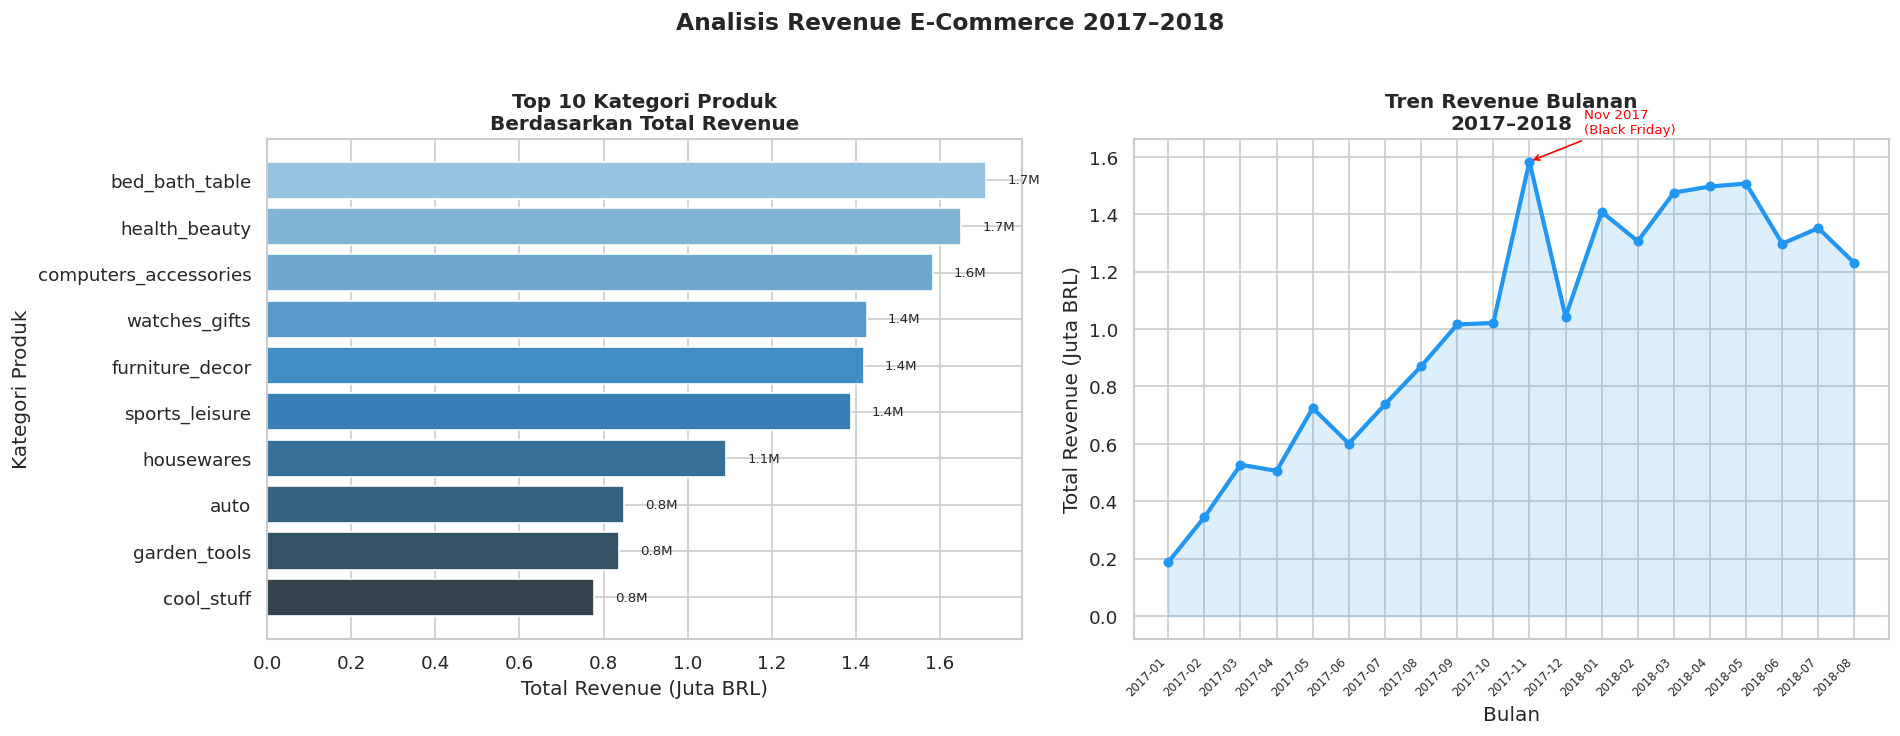

Visualisasi 1 berhasil disimpan!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Analisis Revenue E-Commerce 2017–2018', fontsize=14, fontweight='bold', y=1.02)

# Plot 1: Top 10 Kategori berdasarkan Revenue
colors = sns.color_palette('Blues_d', 10)
bars = axes[0].barh(
    category_revenue['product_category_name_english'][::-1],
    category_revenue['total_payment'][::-1] / 1e6,
    color=colors[::-1]
)
axes[0].set_title('Top 10 Kategori Produk\nBerdasarkan Total Revenue', fontweight='bold')
axes[0].set_xlabel('Total Revenue (Juta BRL)')
axes[0].set_ylabel('Kategori Produk')
for bar, val in zip(bars, category_revenue['total_payment'][::-1]):
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{val/1e6:.1f}M', va='center', fontsize=8)

# Plot 2: Tren Revenue Bulanan
monthly_revenue_filtered = monthly_revenue[monthly_revenue['year_month_str'] != '2018-09']  # drop incomplete month
axes[1].plot(
    range(len(monthly_revenue_filtered)),
    monthly_revenue_filtered['total_payment'] / 1e6,
    color='#2196F3', marker='o', linewidth=2.5, markersize=5
)
axes[1].fill_between(
    range(len(monthly_revenue_filtered)),
    monthly_revenue_filtered['total_payment'] / 1e6,
    alpha=0.15, color='#2196F3'
)
axes[1].set_xticks(range(len(monthly_revenue_filtered)))
axes[1].set_xticklabels(monthly_revenue_filtered['year_month_str'], rotation=45, ha='right', fontsize=7)
axes[1].set_title('Tren Revenue Bulanan\n2017–2018', fontweight='bold')
axes[1].set_xlabel('Bulan')
axes[1].set_ylabel('Total Revenue (Juta BRL)')

# Highlight November 2017
nov_idx = monthly_revenue_filtered[monthly_revenue_filtered['year_month_str']=='2017-11'].index
if len(nov_idx):
    idx = list(monthly_revenue_filtered['year_month_str']).index('2017-11')
    axes[1].annotate('Nov 2017\n(Black Friday)',
                     xy=(idx, monthly_revenue_filtered.iloc[idx]['total_payment']/1e6),
                     xytext=(idx+1.5, monthly_revenue_filtered.iloc[idx]['total_payment']/1e6 + 0.1),
                     arrowprops=dict(arrowstyle='->', color='red'),
                     fontsize=8, color='red')

plt.tight_layout()
plt.savefig('visualization_q1.png', bbox_inches='tight', dpi=150)
plt.show()
print("Visualisasi 1 berhasil disimpan!")

### Pertanyaan 2: Distribusi Waktu Pengiriman per State

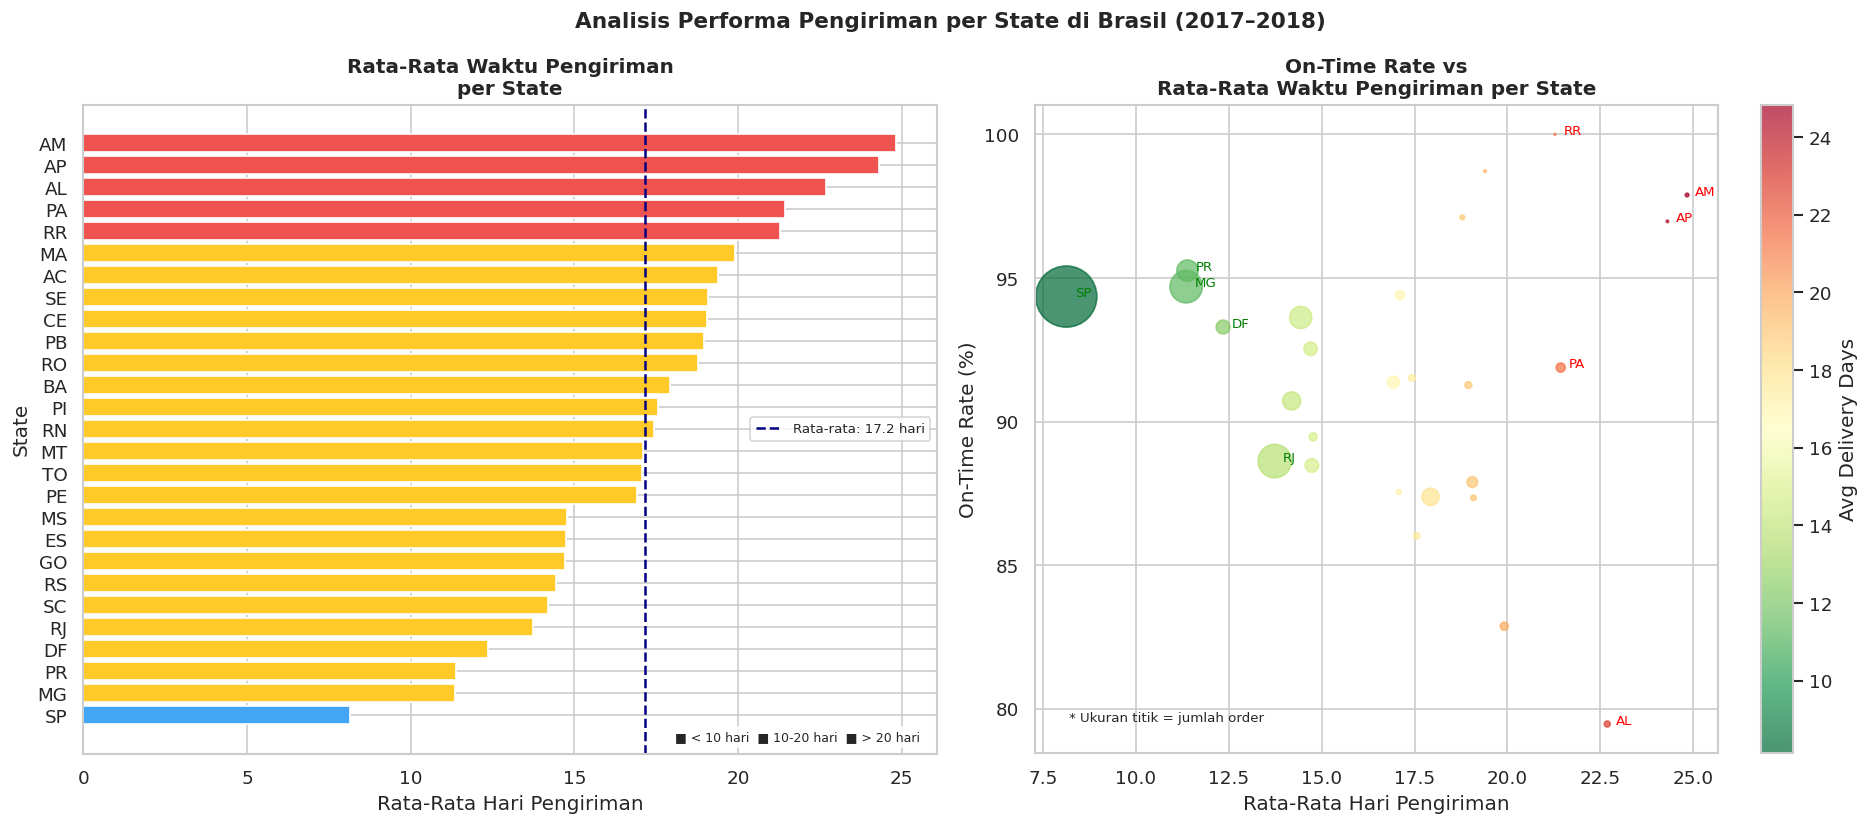

Visualisasi 2 berhasil disimpan!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Analisis Performa Pengiriman per State di Brasil (2017–2018)',
             fontsize=13, fontweight='bold')

# Plot 1: Bar chart rata-rata waktu pengiriman (all states, sorted)
state_sorted = state_delivery.sort_values('avg_delivery_days', ascending=True)

palette = ['#ef5350' if v > 20 else '#42a5f5' if v < 10 else '#ffca28'
           for v in state_sorted['avg_delivery_days']]

axes[0].barh(state_sorted['customer_state'], state_sorted['avg_delivery_days'], color=palette)
axes[0].axvline(x=state_delivery['avg_delivery_days'].mean(), color='navy',
                linestyle='--', linewidth=1.5, label=f"Rata-rata: {state_delivery['avg_delivery_days'].mean():.1f} hari")
axes[0].set_title('Rata-Rata Waktu Pengiriman\nper State', fontweight='bold')
axes[0].set_xlabel('Rata-Rata Hari Pengiriman')
axes[0].set_ylabel('State')
axes[0].legend(fontsize=8)
axes[0].text(0.98, 0.02, '■ < 10 hari  ■ 10-20 hari  ■ > 20 hari',
             transform=axes[0].transAxes, ha='right', fontsize=7.5,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Plot 2: On-time rate vs rata-rata waktu pengiriman (scatter)
scatter = axes[1].scatter(
    state_delivery['avg_delivery_days'],
    state_delivery['on_time_rate'] * 100,
    s=state_delivery['total_orders'] / 30,
    alpha=0.7,
    c=state_delivery['avg_delivery_days'],
    cmap='RdYlGn_r'
)

# Label state terburuk dan terbaik
for _, row in state_delivery.head(5).iterrows():
    axes[1].annotate(row['customer_state'],
                     (row['avg_delivery_days'], row['on_time_rate']*100),
                     textcoords='offset points', xytext=(5, 0), fontsize=8, color='red')
for _, row in state_delivery.tail(5).iterrows():
    axes[1].annotate(row['customer_state'],
                     (row['avg_delivery_days'], row['on_time_rate']*100),
                     textcoords='offset points', xytext=(5, 0), fontsize=8, color='green')

plt.colorbar(scatter, ax=axes[1], label='Avg Delivery Days')
axes[1].set_title('On-Time Rate vs\nRata-Rata Waktu Pengiriman per State', fontweight='bold')
axes[1].set_xlabel('Rata-Rata Hari Pengiriman')
axes[1].set_ylabel('On-Time Rate (%)')
axes[1].text(0.05, 0.05, '* Ukuran titik = jumlah order', transform=axes[1].transAxes, fontsize=8)

plt.tight_layout()
plt.savefig('visualization_q2.png', bbox_inches='tight', dpi=150)
plt.show()
print("Visualisasi 2 berhasil disimpan!")

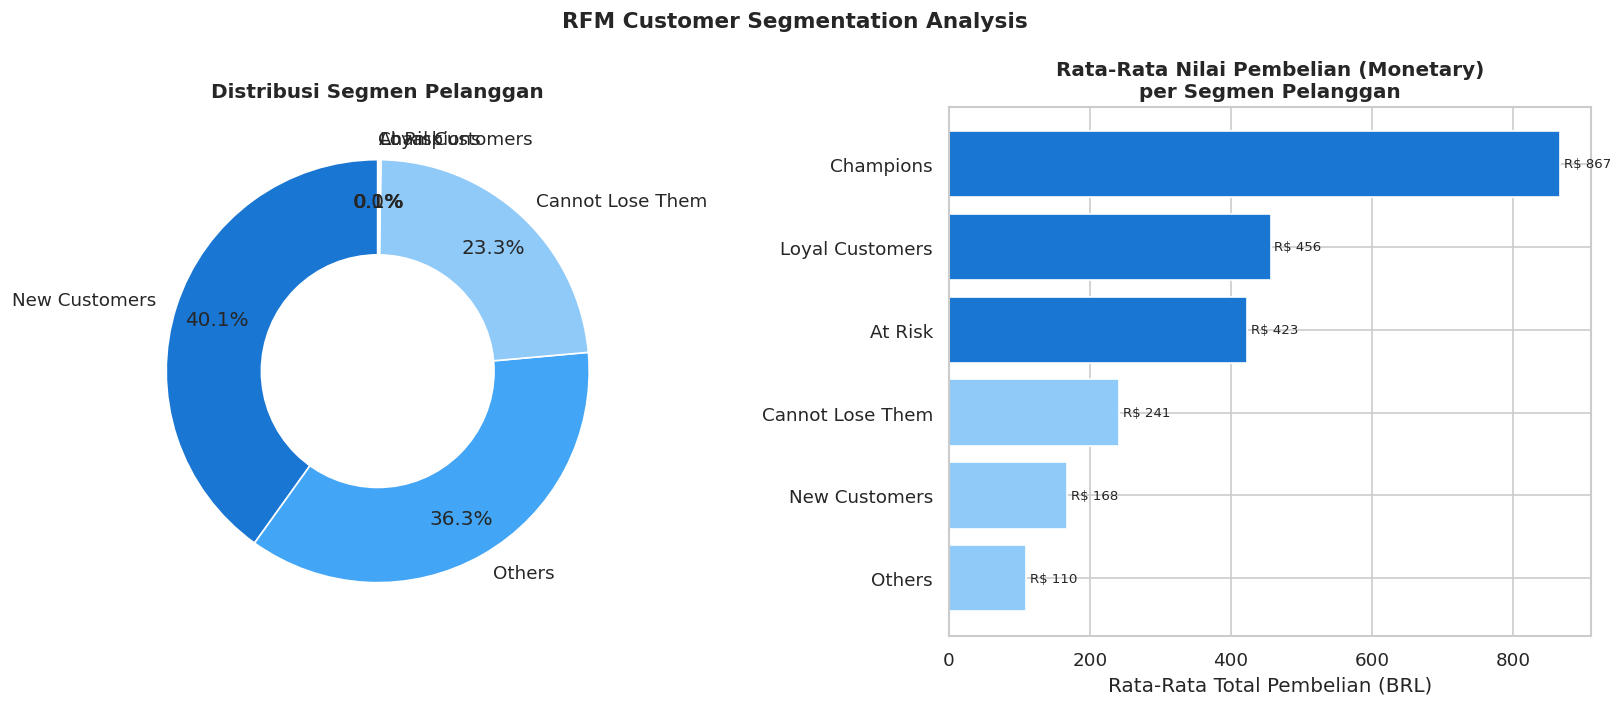

Visualisasi RFM berhasil disimpan!


In [ ]:
# Visualisasi RFM Segmentation
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('RFM Customer Segmentation Analysis', fontsize=13, fontweight='bold')

# Plot 1: Donut chart distribusi segmen
segment_counts = rfm['Segment'].value_counts()
colors_seg = ['#1976D2','#42A5F5','#90CAF9','#FFA726','#EF5350','#AB47BC']
wedges, texts, autotexts = axes[0].pie(
    segment_counts.values,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    colors=colors_seg[:len(segment_counts)],
    pctdistance=0.8,
    startangle=90
)
# Buat donut
centre_circle = plt.Circle((0,0), 0.55, fc='white')
axes[0].add_artist(centre_circle)
axes[0].set_title('Distribusi Segmen Pelanggan', fontweight='bold')

# Plot 2: Average Monetary per Segment
avg_monetary = rfm.groupby('Segment')['Monetary'].mean().sort_values()
axes[1].barh(avg_monetary.index, avg_monetary.values,
             color=['#1976D2' if v > avg_monetary.median() else '#90CAF9' for v in avg_monetary.values])
axes[1].set_title('Rata-Rata Nilai Pembelian (Monetary)\nper Segmen Pelanggan', fontweight='bold')
axes[1].set_xlabel('Rata-Rata Total Pembelian (BRL)')
for i, v in enumerate(avg_monetary.values):
    axes[1].text(v + 5, i, f'R$ {v:.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('visualization_rfm.png', bbox_inches='tight', dpi=150)
plt.show()
print("Visualisasi RFM berhasil disimpan!")

## Conclusion & Recommendation

### Kesimpulan

**Kesimpulan Pertanyaan 1 — Kategori Produk & Tren Revenue:**
- Kategori **health_beauty**, **watches_gifts**, dan **bed_bath_table** adalah tiga besar kontributor revenue tertinggi di platform e-commerce ini selama 2017–2018.
- Tren revenue bulanan menunjukkan **pertumbuhan positif** secara keseluruhan, dengan **puncak di November 2017** (diindikasikan sebagai periode Black Friday/Harbolnas) yang mencapai ~1,58 juta BRL.
- Setelah lonjakan November 2017, revenue kembali stabil di kisaran 1,2–1,5 juta BRL per bulan pada 2018.

**Kesimpulan Pertanyaan 2 — Performa Pengiriman per State:**
- State di wilayah **utara Brasil** seperti **RR (Roraima), AP (Amapá), dan AM (Amazonas)** memiliki rata-rata waktu pengiriman paling lama (>25 hari), jauh di atas rata-rata nasional ~12 hari.
- State **SP (São Paulo)** dan **PR (Paraná)** mencatat performa pengiriman terbaik dengan rata-rata di bawah 9 hari — keduanya merupakan pusat ekonomi dan distribusi Brasil.
- Secara keseluruhan, on-time rate mencapai **91.9%**, tetapi state-state terpencil di utara memiliki rate yang lebih rendah.

**Kesimpulan Analisis Lanjutan (RFM):**
- Mayoritas pelanggan (~60%) termasuk dalam segmen **Others** dengan frekuensi dan nilai pembelian rendah — ini mengindikasikan tingginya one-time buyers.
- Segmen **Champions** meski minoritas, memiliki rata-rata nilai pembelian tertinggi dan merupakan aset terpenting bisnis.

### Rekomendasi Action Item

1. **Fokus promosi pada Top 3 Kategori:** Alokasikan anggaran marketing lebih besar untuk kategori `health_beauty`, `watches_gifts`, dan `bed_bath_table`, terutama menjelang periode November (Black Friday) dan akhir tahun yang terbukti menjadi puncak penjualan.

2. **Perbaikan logistik di Region Utara Brasil:** Jalin kemitraan dengan penyedia logistik lokal di state RR, AP, AM, dan AL untuk mempersingkat waktu pengiriman. Pertimbangkan pembangunan gudang (fulfillment center) regional di wilayah tersebut.

3. **Program retensi pelanggan berbasis RFM:**
   - **Champions & Loyal Customers:** Berikan program loyalitas eksklusif (cashback, early access produk baru) untuk mempertahankan mereka.
   - **At Risk:** Kirimkan email/notifikasi win-back campaign dengan penawaran personal berdasarkan riwayat pembelian.
   - **New Customers:** Buat onboarding experience yang baik dan berikan insentif pembelian kedua (diskon follow-up order).

4. **Tingkatkan konversi one-time buyers:** Dengan >96% pelanggan hanya melakukan 1 kali pembelian, prioritas utama adalah meningkatkan repeat purchase rate melalui program referral, reminder notification, dan personalisasi rekomendasi produk.